# Résolution d'un problème à plusieurs barres 

## Installation of *slides* module

- pip3 install --user git+https://gitlab.com/ganciaux/slides.git


In [1]:
# run - ne pas modifier
%load_ext autoreload
%autoreload 2

from IPython.display import Image
import plot_truss
import numpy as np
from sympy import *
from Slides import math_helper as mh
init_printing()

## Commentaires

- L'indexation sur Python commence à 0 (et non à 1 contrairement à Matlab). C'est pourquoi, nous fixerons nos premiers paramètres (nœud, élément, ligne et colonne des matrices, etc) avec la valeur 0.

- La fonction "mh.print_latex" permet de visualiser les matrices C et Eqn.

- La fonction "plot_truss.plot_truss_structure" permet de représenter les structures d'étude sous forme graphique.

## 1. Matrice de connectivité

Dans cette section, nous tâcherons de comprendre les différentes variables influençant la matrice de connectivité. On considère la structure suivante comme référence. 

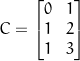

None


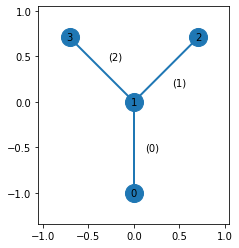

In [2]:
# Run - ne pas modifier

positions = [
    [0, -1],
    [0, 0],
    np.array([1, 1])/np.sqrt(2),
    np.array([-1, 1])/np.sqrt(2)
]

conn = [
    [0, 1],
    [1, 2],
    [1, 3]
]

mh.print_latex("C = {0}", Matrix(conn))
plot_truss.plot_truss_structure(positions, conn)

### 1.1.  Influence de la numérotation des éléments. 

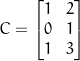

In [3]:
# Inverser les lignes de conn

conn = [
    [1, 2],
    [0, 1],
    [1, 3]
]

mh.print_latex("C = {0}", Matrix(conn))


#### Question:

Quel impact y a-t-il lorsque nous inversons les lignes de la matrice de connectivité sur la structure?

#### Réponse: 

_Saisir votre réponse ici_


None


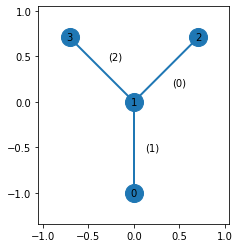

In [4]:
# Run - ne pas modifer

positions = [
    [0, -1],
    [0, 0],
    np.array([1, 1])/np.sqrt(2),
    np.array([-1, 1])/np.sqrt(2)
]

plot_truss.plot_truss_structure(positions, conn)

### 1.2. Influence de la position des nœuds. 

In [5]:
# Permuter les nœuds 1 et 3 dans la matrice "positions"

positions = [
    [0, -1],
    np.array([-1, 1])/np.sqrt(2),
    np.array([1, 1])/np.sqrt(2),
    [0, 0]
]

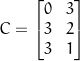

In [6]:
# Modifier la matrice de connectivité associée à ce changement

conn = [
    [0, 3],
    [3, 2],
    [3, 1]
]

mh.print_latex("C = {0}", Matrix(conn))

None


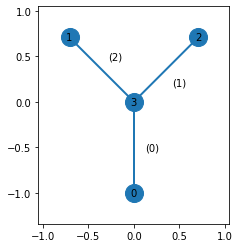

In [7]:
# Vérifier sur la figure ci-dessous que les nœuds 1 et 3 ont bien permuté

# Run - ne pas modifier

plot_truss.plot_truss_structure(positions, conn)

#### Question:

Quel impact y a-t-il lorsque l'on permutte les nœuds sur la matrice de connectivité?

#### Réponse:

_Saisir votre réponse ici_


### 1.3. Dessiner sur papier la structure obtenue si nous définissons la matrice C et la position des nœuds comme suit.

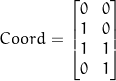

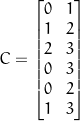

In [8]:
# Run - ne pas modifier

positions = [
    [0, 0],
    [1, 0],
    [1, 1],
    [0, 1]
]
mh.print_latex("Coord = {0}", Matrix(positions))


conn = [
    [0, 1],
    [1, 2],
    [2, 3],
    [0, 3],
    [0, 2],
    [1, 3],
]
mh.print_latex("C = {0}", Matrix(conn))

#### Réponse:

None


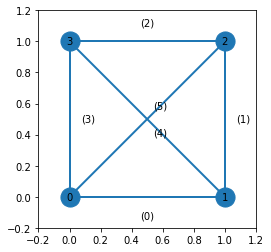

In [9]:
plot_truss.plot_truss_structure(positions, conn)

## 2. La matrice de numérotation d'équation

Dans cette section, nous tâcherons de comprendre les différentes variables influençant la matrice de numérotation d'équation par élément. Pour cela, reprenons notre structure de référence. On ajoute maintenant les indices des ddl \[i; j\] pour chaque nœud.

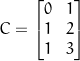

None


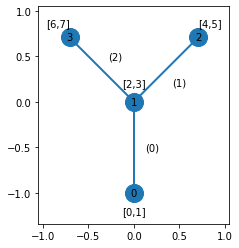

In [10]:
# On reprend notre structure de référence à laquelle on ajoute nos ddl par nœud

# Run - ne pas modifier

positions = [
    [0, -1],
    [0, 0],
    np.array([1, 1])/np.sqrt(2),
    np.array([-1, 1])/np.sqrt(2)
]

conn = [
    [0, 1],
    [1, 2],
    [1, 3]
]

mh.print_latex("C = {0}", Matrix(conn))
ret = plot_truss.plot_truss_structure(positions, conn, plot_eqn="packed")

### 2.1. Définition de la matrice de numérotation par nœud Eqn

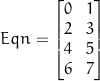

In [11]:
# On ajoute la variable "eqn_node" à la fonction mh.print_latex

# Run - ne pas modifier

mh.print_latex("Eqn = {0}", Matrix(ret['eqn_node'])) 

#### Question:

Que représente cette matrice ? Définir à quoi correspondent les lignes et les colonnes.

#### Réponse:

_Saisir votre réponse ici_

### 2.2. Définition de la matrice de numérotation par élément Eqe

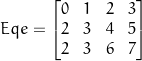

In [12]:
# On ajoute la variable "eqn_elem" à la fonction mh.print_latex

# Run - ne pas modifier

mh.print_latex("Eqe = {0}", Matrix(ret['eqn_elem']))

#### Question:

Que représente cette matrice ? Définir à quoi correspondent les lignes et les colonnes afin de bien comprendre la différence entre Eqn et Eqe.

#### Réponse:

_Saisir votre réponse ici_

### 2.3. Influence de la définition des ddl associés à chacun des nœuds.

None


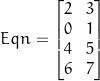

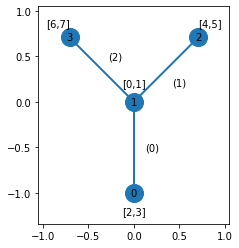

In [13]:
# Inverser la ligne (0) et la ligne (1) de la matrice eqn_node

eqn_node = np.array(
    [[2, 3],
     [0, 1],
     [4, 5],
     [6, 7]]
)

# Run - ne pas modifier

ret = plot_truss.plot_truss_structure(positions, conn, plot_eqn=eqn_node)
mh.print_latex("Eqn = {0}", Matrix(ret['eqn_node']))

#### Question:

Quel impact cela aura-t-il sur la matrice de numéro d'équation par éléments ?

#### Réponse:

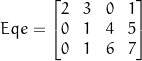

In [14]:
# Run - ne pas modifier

mh.print_latex("Eqe = {0}", Matrix(ret['eqn_elem']))

### 2.4. Influence de la position des nœuds

In [15]:
# Permuter les nœuds 1 et 2 dans la matrice "positions"

positions = [
    [0, -1],
    np.array([1, 1])/np.sqrt(2),
    [0, 0],
    np.array([-1, 1])/np.sqrt(2)
]

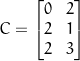

In [16]:
# Modifier la matrice de connectivité associée à ce changement

conn = [
    [0, 2],
    [2, 1],
    [2, 3]
]

mh.print_latex("C = {0}", Matrix(conn))

None


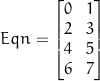

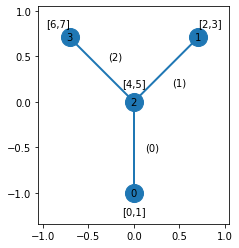

In [17]:
# Vérifier sur la figure ci-dessous que les nœuds 1 et 2 ont bien permuté

# Run - ne pas modifier

ret = plot_truss.plot_truss_structure(positions, conn, plot_eqn="packed")
mh.print_latex("Eqn = {0}", Matrix(ret['eqn_node']))

#### Question:

Quel impact cela aura-t-il sur la matrice de numérotation d'équation par élément Eqe?

#### Réponse:

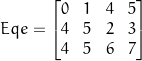

In [18]:
# Run - ne pas modifier

mh.print_latex("Eqe = {0}", Matrix(ret['eqn_elem']))

### 2.5. Sur la base de l'exemple 1.3. , comment définiriez vous les matrices Eqn et Eqe?

#### Réponse:

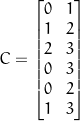

None


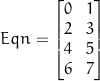

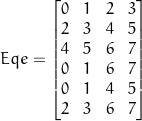

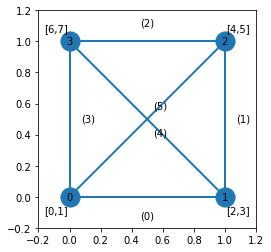

In [19]:
# Run - ne pas modifier

positions = [
    [0, 0],
    [1, 0],
    [1, 1],
    [0, 1]
]

conn = [
    [0, 1],
    [1, 2],
    [2, 3],
    [0, 3],
    [0, 2],
    [1, 3],
]

mh.print_latex("C = {0}", Matrix(conn))

ret = plot_truss.plot_truss_structure(positions, conn, plot_eqn="packed")
mh.print_latex("Eqn = {0}", Matrix(ret['eqn_node']))
mh.print_latex("Eqe = {0}", Matrix(ret['eqn_elem']))

### 2.6. Influence du regroupement les ddl

Reprenons notre structure de référence. Dans cette partie, nous changeons la façon de grouper les ddls; nous choissisons de ne plus les grouper par nœud, c'est-à-dire (d1x, d1y, d2x, d2y) mais par variable (d1x, d2x, d1y, d2y). 

#### Question:

Comment s'écrirait la matrice Eqe? 

Quel serait l'influence de ce changement sur la matrice de raideur K? 

En quoi un tel changement serait utile?

#### Réponse:

_Saisir votre réponse ici_

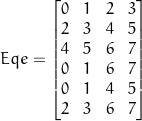

In [20]:
# Run - ne pas modifier

mh.print_latex("Eqe = {0}", Matrix(ret['eqn_elem']))

## 3. Matrice de raideur

Dans cette partie, nous nous intéresserons à la matrice de raideur selon la géométrie du problème.

#### 3.1. Prenons l'exemple d'une barre. Testez différentes valeurs d'angle theta. Observez son influence sur la matrice de raideur locale (exprimé dans le repère global). Dans les cas particuliers de theta=90degrés et theta=180degrés, comparez la matrice K obtenue par rapport à la matrice K locale d'une barre. 

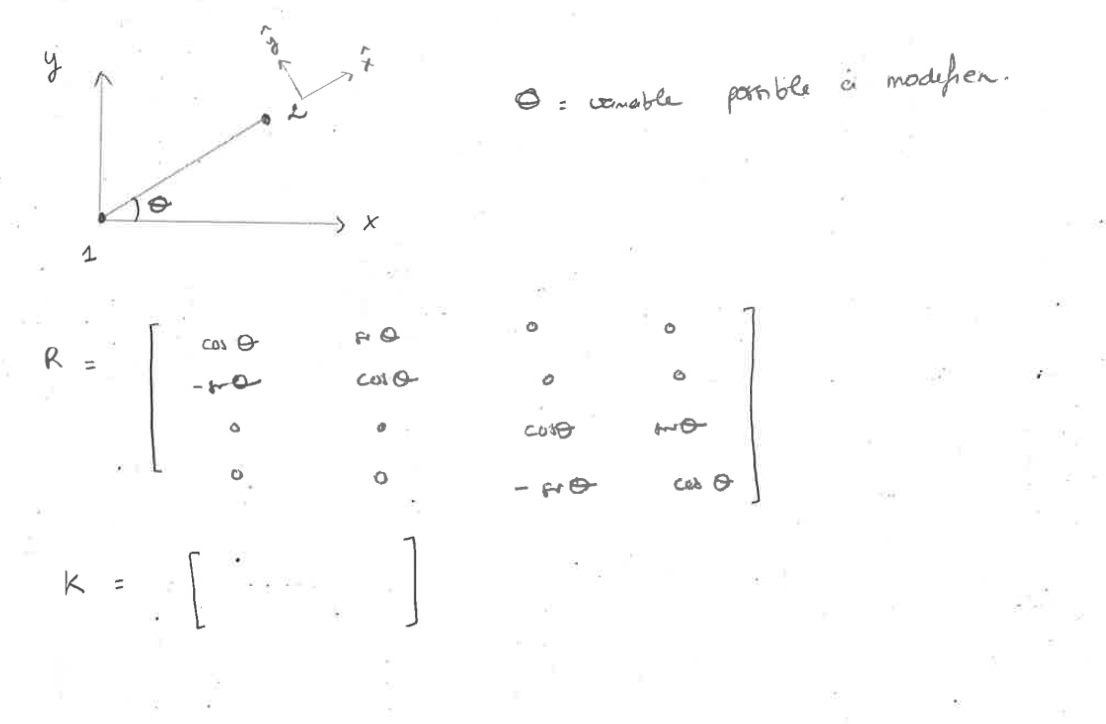

In [21]:
PATH = "./Figure_Notebook1/"
Image(filename = PATH + "3.1.png", width=600, height=600)

In [84]:
# define an angle
theta = Symbol(r'\theta', real=True)
# define a length
L = Symbol('L', real=True, positive=True)
# define the coordinates of two points
coordinates = Matrix([[0, 0], [L*cos(theta), L*sin(theta)]])
# adds a single bar connecting the nodes
connectivity = np.array([[0, 1]])

None


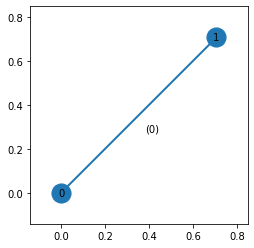

In [85]:
# shows the example with numerical values
app_num = {L: 1, theta: pi/4}

positions = np.array(coordinates.subs(app_num).evalf(), dtype=float)
ret = plot_truss.plot_truss_structure(positions, connectivity)

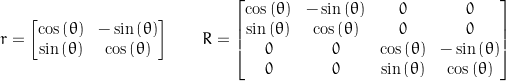

In [86]:
# compute the rotation
p1, p2 = coordinates[0, :], coordinates[1, :]
r, _L = plot_truss.calculerMatriceRotation(p1, p2)

R = zeros(4, 4)
R[:2, :2] = r
R[2:, 2:] = r

mh.print_latex(r'r = {0} \qquad R = {1}', r, R)

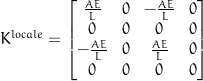

In [87]:
# Compute locale stiffness matrix
E, A = symbols('E A', positive=True, real=True)
Klocale = plot_truss.calculerMatriceRigiditeLocale(E*A/L)
mh.print_latex('K^{{locale}} = {0}', Klocale)

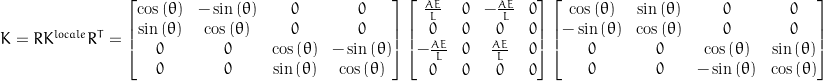

In [88]:
mh.print_latex(r'K = R K^{{locale}} R^T = {0}{1}{2}', R, Klocale, R.T)

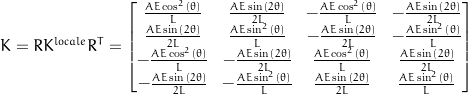

In [89]:
mh.print_latex(r'K = R K^{{locale}} R^T = {0}', simplify(R@Klocale@R.T))

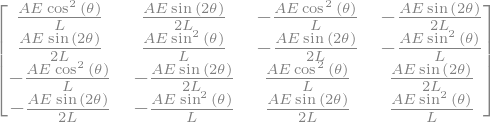

In [90]:
K = plot_truss.assemblerMatriceRigidite(coordinates, connectivity, [E*A])
K

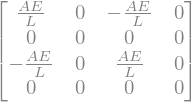

In [91]:
K.subs(theta, 0)

None


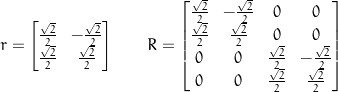

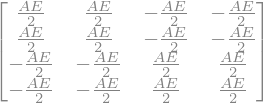

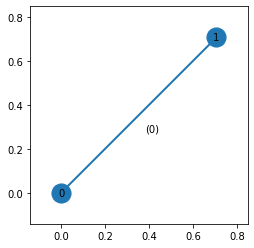

In [92]:
# replot with the numerical values
app_num = {L: 1, theta: pi/4}

positions = np.array(coordinates.subs(app_num).evalf(), dtype=float)
ret = plot_truss.plot_truss_structure(positions, connectivity)

mh.print_latex(r'r = {0} \qquad R = {1}', r.subs(app_num), R.subs(app_num))
K.subs(app_num)

Réponse: Pour theta=90, cela revient à exprimer la matrice locale d'une barre en échangeant les x et y. Pour theta=180, la matrice K est inchangée.

None


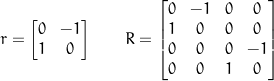

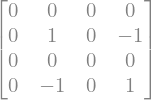

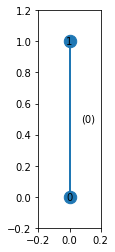

In [93]:
# replot with the numerical values
app_num = {L: 1, theta: pi/2, A*E: 1}

positions = np.array(coordinates.subs(app_num).evalf(), dtype=float)
ret = plot_truss.plot_truss_structure(positions, connectivity)

mh.print_latex(r'r = {0} \qquad R = {1}', r.subs(app_num), R.subs(app_num))
K.subs(app_num)

#### 3.2. a) A partir de la matrice de connectivité et de coordonnées de nœuds de la structure suivante, quelle serait la forme de la matrice K?

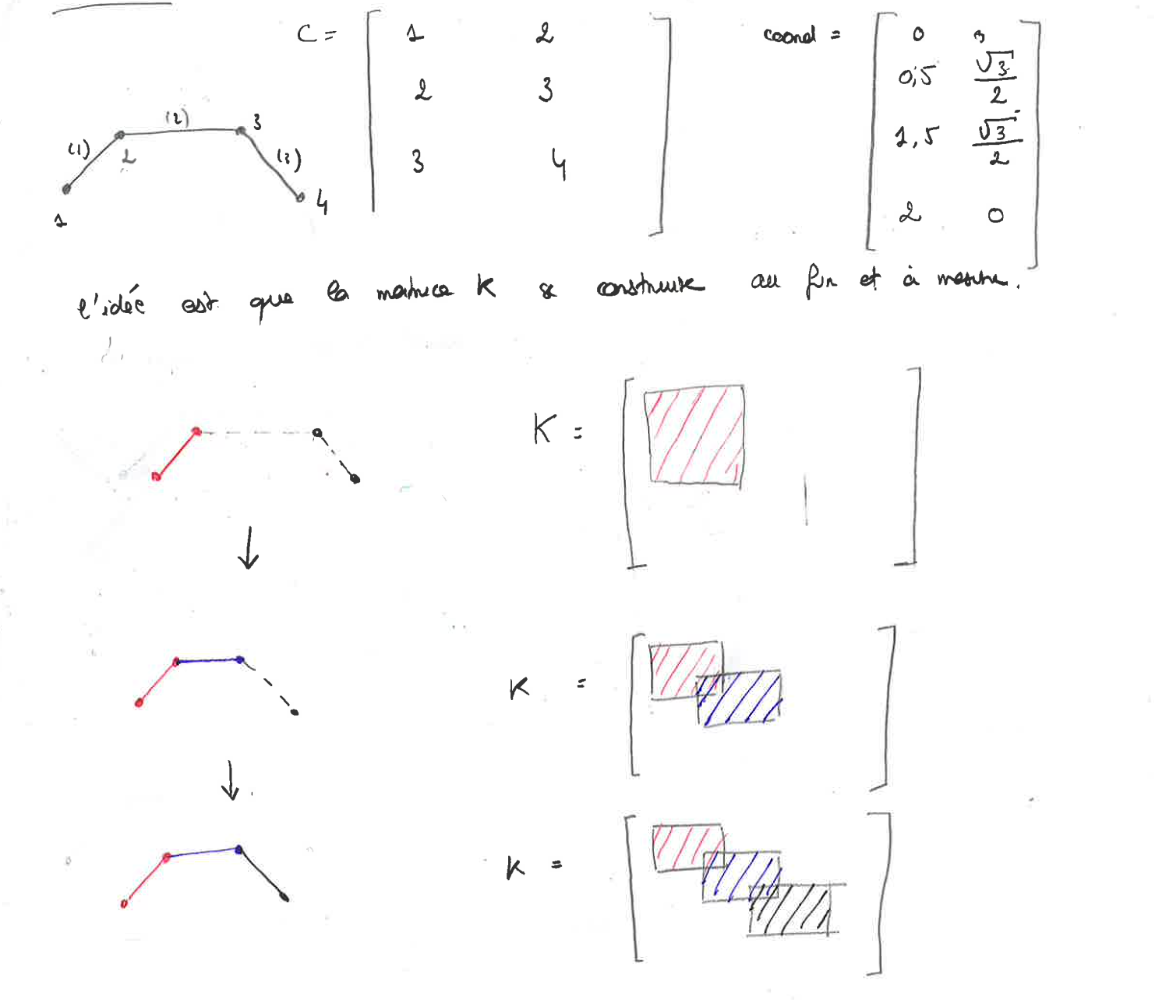

In [94]:
PATH = "./Figure_Notebook1/"
Image(filename = PATH + "3.2_a_new.png", width=600, height=600)

None


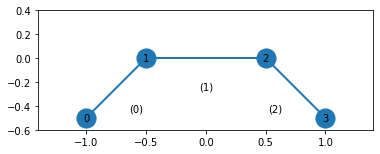

In [95]:
# define the coordinates of two points
coordinates = np.array([
    [-1., -.5],
    [-.5, 0],
    [.5, 0],
    [1., -.5]])
# adds a single bar connecting the nodes
connectivity = np.array([
    [0, 1],
    [1, 2],
    [2, 3]
])
ret = plot_truss.plot_truss_structure(coordinates, connectivity)

[(0.0, 0.5, 0.0), (0.0, 0.75, 0.75), (0.0, 0.75, 0.75)]


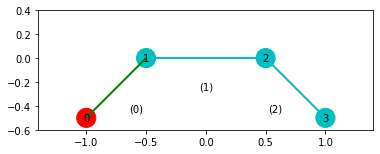

In [96]:
# coloring a structure

elem_colors = np.zeros(connectivity.shape[0], dtype=str)
elem_colors[0] = 'g'

node_colors = np.zeros(coordinates.shape[0], dtype=str)
node_colors[0] = 'r'

ret = plot_truss.plot_truss_structure(coordinates, connectivity, elem_colors=elem_colors, node_colors=node_colors)

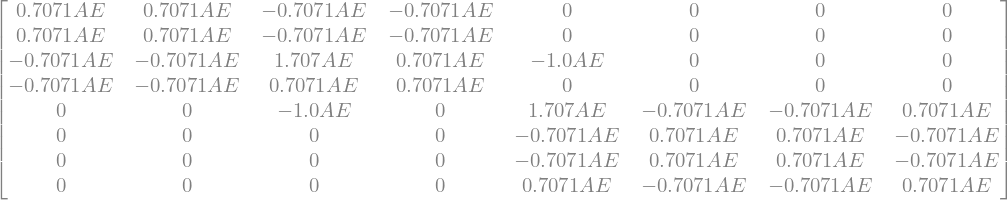

In [156]:
materiau = E*A*np.ones(connectivity.shape[0], dtype=object)

K = plot_truss.assemblerMatriceRigidite(coordinates, connectivity, materiau)
K.evalf(4)

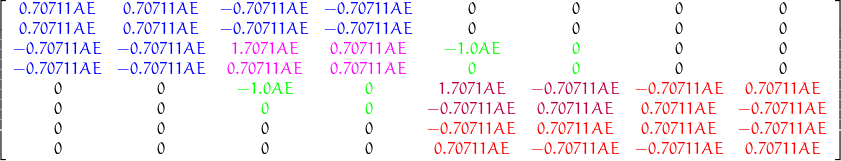

In [241]:
elem_colors = np.array(['b', 'g', 'r'])
K = plot_truss.assemblerMatriceRigidite(coordinates, connectivity, materiau, elem_colors=elem_colors)
K.evalf(5)

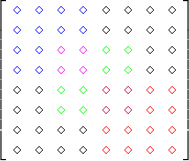

In [257]:
K.profile()

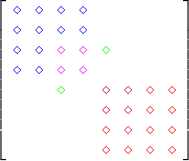

In [259]:
K.profile(remove_zeros=True)

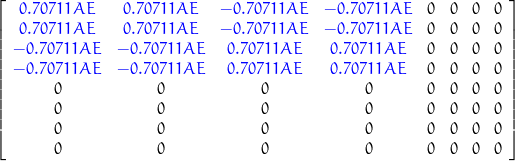

In [266]:
elem_colors = np.array(['b', 'g', 'r'])
K = plot_truss.assemblerMatriceRigidite(coordinates, connectivity, materiau, elem_colors=elem_colors,
                                        elem_to_assemble=[0])
K.evalf(5)

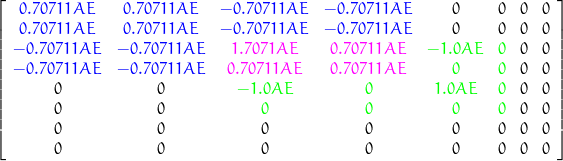

In [267]:
elem_colors = np.array(['b', 'g', 'r'])
K = plot_truss.assemblerMatriceRigidite(coordinates, connectivity, materiau, elem_colors=elem_colors,
                                        elem_to_assemble=[0, 1])
K.evalf(5)

#### b) On connecte maintenant les nœuds 1 et 3 ensembles, et les nœuds 2 et 4. Commentez sur la forme de la matrice locale que nous ajoutons. Quelle est la matrice K globale?

In [ ]:
PATH = "./Figure_Notebook1/"
Image(filename = PATH + "3.2_b_new.png", width=600, height=600)

#### 3.4. Complétez ce code à trou permettant l'assemblage d'une matrice. Vérifier le code avec l'exemple que vous avez défini précédemment. Dans un premier temps, supposez que les barres ont toutes la même rigidité. Comment s'implémenterait le code lorsque la rigidité des barres est différente?

In [ ]:
#Input:
Ne=  #le nombre d'éléments

C= #matrice de connectivité
Eqn= #la matrice de numérotation d'équation

coord= #coordonées x (1ere colonne) et y (2ieme colonne) pour chaque nœud (ligne)
k= # [kN/m] rigidité des barres 

K= #matrice de raideur locale dans le repère local

In [ ]:
#Output:
K_g #matrice de raideur globale

In [ ]:
#Code:
#pour chaque élément e
for e in :
    
    #double boucle sur les ddfs locaux (2D)
    for i in:
        for j in:
            
            #implémenter la matrice de rotation
            n1= #noeud 1 pour l'élément e
            n2= #noeud 1 pour l'élément e
            L= #longeur de l'élément barre e
            cos=
            sin=
            lambda_matrix= #bloc matrice de la matrice de raideur
            R= #matrice de rotation
            
            #matrice de raideur locale dans le repère global
            K_loc=
            
            #on récupère les ddls dans le repère global grâce à la matrice Eqn
            gi=
            gj=
            
            #on somme les contributions de chaque élément
            K_g=
print(K_g)